In [2]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import pytrec_eval
import random
print(openai.__version__)
# client = OpenAI(api_key=api_key)
apikey = ""
client = AsyncOpenAI(api_key=apikey)

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

random.seed(0)

1.90.0


In [3]:
import sys
sys.path.append('./..')
from order_by.sorting import *
from order_by.utils import *
from prompts.all_prompts import *
from order_by.pointwise import *

In [4]:
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class SearchResult:
    docid: str
    score: float
    text: str

In [5]:
import ir_datasets

# # Discover all available msmarco-passage-v2 variants
# for d in ir_datasets.registry:
#     if "msmarco-passage" in d:
#         print(d)


# # Load TREC DL 2019 with MS MARCO v1 passage corpus
ds = ir_datasets.load("msmarco-passage/trec-dl-2019")




In [6]:
print("Docs:", ds.docs_count())      # Number of docs
print("Queries:", ds.queries_count())# Number of queries
print("Qrels:", ds.qrels_count())    # Number of qrels

passage_length = 1024
query_map = {}
for query in ds.queries_iter():
    # query.query_id → string ID
    # query.text → raw query text
    gpt_encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")
    query_map[query.query_id] = gpt_encoding.decode( gpt_encoding.encode(query.text)[:passage_length] )
print(len(query_map))


Docs: 8841823
Queries: 200
Qrels: 9260
200


In [7]:
doc_lookup = {}
for doc in ds.docs_iter():
    doc_lookup[doc.doc_id] = {
        "contents": doc.text
    }
    # Add title if it exists in dataset (some have no title)
    if hasattr(doc, "title") and doc.title:
        doc_lookup[doc.doc_id]["title"] = doc.title

In [10]:
bm25_dl19_txt = '../data/run.msmarco-v1-passage.bm25-default.dl19.txt'
def load_run_file(path, query_map, doc_lookup, hits=100):
    first_stage_rankings = []
    query_id_to_list = defaultdict(list)
    with open(path, 'r') as f:
        current_qid = None
        current_ranking = []
        for line in tqdm(f):
            qid, _, docid, _, score, _ = line.strip().split()
            if qid not in query_map:
                print(qid)
                print('???')
                continue
                
            doc_data = doc_lookup[docid]
            text = doc_data["contents"]
            if "title" in doc_data:
                text = f'{doc_data["title"]} {text}'

            text = gpt_encoding.decode(gpt_encoding.encode(text)[:passage_length])
            
            
            query_id_to_list[qid].append(SearchResult(docid=docid, score=float(score), text=text))
            
    for qid, current_ranking in query_id_to_list.items():
        first_stage_rankings.append((qid, query_map[qid], current_ranking[:hits]))
    return first_stage_rankings

In [11]:
first_stage_rankings = load_run_file(bm25_dl19_txt, query_map, doc_lookup, 100)

43000it [00:07, 6113.10it/s]


In [12]:
print(len(first_stage_rankings))

43


# Filter with BM25

In [9]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'

In [10]:


# Build qrels dict
qrels_by_qid = defaultdict(dict)
for q in ds.qrels_iter():                      # has query_id, doc_id, relevance
    qrels_by_qid[str(q.query_id)][str(q.doc_id)] = int(q.relevance)
qrels_by_qid = dict(qrels_by_qid)

evaluator = pytrec_eval.RelevanceEvaluator(qrels_by_qid, {'ndcg_cut.10'})

bm25_run = {}
for qid, query, ranking in first_stage_rankings:
    bm25_run[str(qid)] = {str(r.docid): float(r.score) for r in ranking}

metrics = evaluator.evaluate(bm25_run)
print(metrics[str('19335')]['ndcg_cut_10'])  # per-query
mean_ndcg10 = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
print("BM25 Mean nDCG@10:", mean_ndcg10)

0.5755597276220168
BM25 Mean nDCG@10: 0.505831002439907


In [11]:
# print(qrels_by_qid['19335'])
# print(bm25_run['19335'])

In [12]:
    
def tokens2price(model, in_tokens, out_tokens):
    """
    Calculate the API cost given the model and number of input/output tokens.

    Pricing (as of Sep 2025):
    - gpt-4o:       $2.50 per 1M input tokens, $10.00 per 1M output tokens
    - gpt-4o-mini:  $0.150 per 1M input tokens, $0.600 per 1M output tokens
    """
    if model == 'gpt-4o':
        input_rate = 2.50 / 1_000_000
        output_rate = 10.00 / 1_000_000
    elif model == 'gpt-4o-mini':
        input_rate = 0.150 / 1_000_000
        output_rate = 0.600 / 1_000_000
    else:
        raise ValueError(f"Unknown model: {model}")

    total_cost = in_tokens * input_rate + out_tokens * output_rate
    return round(total_cost, 6) 
        

# Pointwise experiments

In [13]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking in tqdm(first_stage_rankings):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pointwise_prompt_template = passage_pointwise_prompt_template.format_map(SafeDict(question=query))
        
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences =\
            await pointwise_sort(passage_list, client, pointwise_prompt_template,
                                 modelname, float, PointwiseRelevanceKey)
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid, query)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) )
        external_pointwise_prompt_template = passage_external_pointwise_prompt_template.format_map(SafeDict(question=query))
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences, _ =\
            await external_pointwise_sort(passage_list, external_values, client, external_pointwise_prompt_template,\
                                          modelname, float, 0.1, isPassage=True)
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_external_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, extrernal pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    

 14%|██████▏                                     | 6/43 [00:46<04:36,  7.48s/it]

exception=1 validation error for PassagePointwiseReasoning
  Invalid JSON: EOF while parsing a string at line 4 column 222 [type=json_invalid, input_value='{\n  "steps": [\n    {\n...not directly answer the', input_type=str]
    For further information visit https://errors.pydantic.dev/2.6/v/json_invalid
exception=1 validation error for PassagePointwiseReasoning
  Invalid JSON: EOF while parsing a string at line 4 column 229 [type=json_invalid, input_value='{\n  "steps": [\n    {\n...ich directly relates to', input_type=str]
    For further information visit https://errors.pydantic.dev/2.6/v/json_invalid


100%|███████████████████████████████████████████| 43/43 [05:48<00:00,  8.10s/it]


gpt-4o-mini, pointwise Mean nDCG@10: 0.7054242580536398
tokens: 1610183, price: 0.390589


  0%|                                                    | 0/43 [00:00<?, ?it/s]

...

1129237 hydrogen is a liquid below what temperature
from window m=4: 3.0 from window 2m: 2.8
from window m=4: 2.5 from window 2m: 1.0
from window m=4: 0.5 from window 2m: 0.0
Final memory size for external pointwise: m = 4 (agreement = 0.62)


 98%|██████████████████████████████████████████ | 42/43 [18:29<00:32, 32.82s/it]

1133167 how is the weather in jamaica
from window m=2: 2.5 from window 2m: 2.0
from window m=2: 1.5 from window 2m: 2.5
from window m=2: 2.0 from window 2m: 2.8
Final memory size for external pointwise: m = 2 (agreement = 0.25)


100%|███████████████████████████████████████████| 43/43 [18:52<00:00, 26.34s/it]

gpt-4o, extrernal pointwise Mean nDCG@10: 0.6725699725291121
tokens: 1173510, price: 4.86411


In [ ]:
gpt-4o-mini, pointwise Mean nDCG@10: 0.7054242580536398
tokens: 1610183, price: 0.390589
        
gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.6516519578766975
tokens: 888131, price: 0.298138
        
gpt-4o, pointwise Mean nDCG@10: 0.6851303581701533
tokens: 1807430, price: 12.705545
    
gpt-4o, extrernal pointwise Mean nDCG@10: 0.6704477449817059
tokens: 720900, price: 3.731895

# Pairwise experiments

In [14]:
print('start')

start


In [15]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:        
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 1
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        run[str(qid)] = {
            str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 3
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        run[str(qid)] = {
            str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    

  0%|                                                    | 0/43 [00:00<?, ?it/s]

19335


  2%|█                                           | 1/43 [00:00<00:21,  1.95it/s]

47923


  5%|██                                          | 2/43 [00:00<00:17,  2.32it/s]

...

1129237


 98%|█████████████████████████████████████ | 42/43 [15:05:07<20:52, 1252.66s/it]

1133167


100%|██████████████████████████████████████| 43/43 [15:13:22<00:00, 1274.47s/it]

gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7383429642047581
tokens: 39522832, price: 243.41737


In [ ]:
gpt-4o-mini, quick_sort Mean nDCG@10: 0.7094846436237204
tokens: 15159756, price: 5.593763
        
gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.6943515063626197
tokens: 33669471, price: 12.218578
        
gpt-4o, quick_sort Mean nDCG@10: 0.7351607877533932
tokens: 18832854, price: 122.357505
        
gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7383429642047581
tokens: 39522832, price: 243.41737

In [17]:
for modelname in ["gpt-4o-mini", "gpt-4o"]:    
    memory = [4]
    if "mini" in modelname:
        memory = [4]
    
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for qid, query, ranking in tqdm(first_stage_rankings):
            print(qid)
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) ) 

            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_bubble_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True)

            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")



        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for qid, query, ranking in tqdm(first_stage_rankings):
            print(qid)
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) ) 

            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_merge_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True)

            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


  0%|                                                    | 0/43 [00:00<?, ?it/s]

19335


  2%|█                                           | 1/43 [00:00<00:24,  1.73it/s]

47923


  5%|██                                          | 2/43 [00:01<00:27,  1.51it/s]

...

1121402
1121709


 95%|█████████████████████████████████████████  | 41/43 [00:05<00:00,  7.73it/s]

1124210
1129237


100%|███████████████████████████████████████████| 43/43 [00:05<00:00,  8.16it/s]

1133167
gpt-4o, external_merge_sort Mean nDCG@10: 0.7395685322543967
tokens: 5990003, price: 33.35525


In [ ]:
gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.7153217587714527
tokens: 39869401, price: 13.535094

gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.7140558683618574
tokens: 6263645, price: 2.135086

gpt-4o, external_bubble_sort Mean nDCG@10: 0.7313444288489481
tokens: 38683494, price: 213.587565

gpt-4o, external_merge_sort Mean nDCG@10: 0.7395685322543967
tokens: 5990003, price: 33.35525

Fitted parameters:
A = 0.0160
B = 0.6554
x0 = 0.0000


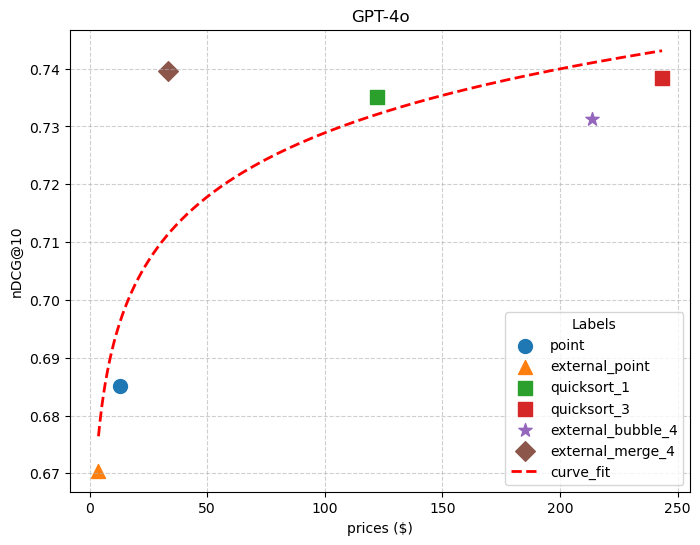

In [13]:
# gpt-4o, pointwise Mean nDCG@10: 0.6851303581701533
# tokens: 1807430, price: 12.705545
    
# gpt-4o, extrernal pointwise Mean nDCG@10: 0.6704477449817059
# tokens: 720900, price: 3.731895

# gpt-4o, quick_sort Mean nDCG@10: 0.7351607877533932
# tokens: 18832854, price: 122.357505
        
# gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7383429642047581
# tokens: 39522832, price: 243.41737

# gpt-4o, external_bubble_sort Mean nDCG@10: 0.7313444288489481
# tokens: 38683494, price: 213.587565

# gpt-4o, external_merge_sort Mean nDCG@10: 0.7395685322543967
# tokens: 5990003, price: 33.35525

kendalltau = [0.6851303581701533, 0.6704477449817059,
              0.7351607877533932, 0.7383429642047581,
              0.7313444288489481, 0.7395685322543967
             ]
tokens = [1807430, 720900,
          18832854, 39522832,
          38683494, 5990003
         ]
prices = [12.705545, 3.731895,
          122.357505, 243.41737,
          213.587565, 33.35525
         ]

tokens = [t/(43.0) for t in tokens]
prices = [p for p in prices]


dot_labels = ["point", "external_point",
              "quicksort_1", "quicksort_3",
              "external_bubble_4", "external_merge_4"
             ]
markers = ['o', '^',
           's', 's',
           '*', 'D'
          ] 


            
# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)



    
def log_linear(x, A, B, x0):
    return A * np.log(x + x0) + B

y_points = kendalltau[:]
x_points = prices[:]
x_points = np.array(x_points, dtype=float)
y_points = np.array(y_points, dtype=float)
# Initial guess and bounds (ensure x + x0 > 0 ⇒ x0 > -min(x); we keep x0 >= 1e-8)
p0 = [y_points.ptp(), y_points.min(), 0.1]
bounds = ([-np.inf, -np.inf, 1e-8], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(log_linear, x_points, y_points, p0=p0, bounds=bounds, maxfev=50000)
A, B, x0 = popt

# R^2
y_hat = log_linear(x_points, *popt)
ss_res = np.sum((y_points - y_hat)**2)
ss_tot = np.sum((y_points - y_points.mean())**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Smooth curve for plotting
x_fit = np.linspace(x_points.min(), x_points.max(), 1000)
y_fit = log_linear(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', linewidth=2, label="curve_fit")


print("Fitted parameters:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"x0 = {x0:.4f}")
    

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("prices ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Fitted parameters:
A = 0.0082
B = 0.6909
x0 = 0.0000


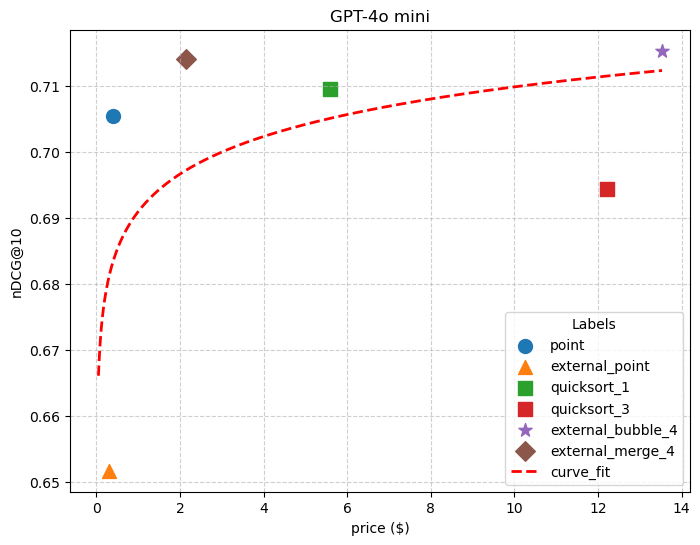

In [21]:
# gpt-4o-mini, pointwise Mean nDCG@10: 0.7054242580536398
# tokens: 1610183, price: 0.390589
        
# gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.6516519578766975
# tokens: 888131, price: 0.298138
        
# gpt-4o-mini, quick_sort Mean nDCG@10: 0.7094846436237204
# tokens: 15159756, price: 5.593763
        
# gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.6943515063626197
# tokens: 33669471, price: 12.218578
        
# gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.7153217587714527
# tokens: 39869401, price: 13.535094

# gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.7140558683618574
# tokens: 6263645, price: 2.135086
        
kendalltau = [0.7054242580536398, 0.6516519578766975,
              0.7094846436237204, 0.6943515063626197,
              0.7153217587714527, 0.7140558683618574
             ]
tokens = [1610183, 888131,
          15159756, 33669471,
          39869401, 6263645
         ]
prices = [0.390589, 0.298138,
          5.593763, 12.218578,
          13.535094, 2.135086
         ]


tokens = [t/(43.0) for t in tokens]
prices = [p for p in prices]

dot_labels = ["point", "external_point",
              "quicksort_1", "quicksort_3",
              "external_bubble_4", "external_merge_4"
             ]
markers = ['o', '^',
           's', 's',
           '*', 'D'
          ] 


            
# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)


    
def log_linear(x, A, B, x0):
    return A * np.log(x + x0) + B

y_points = kendalltau[:]
x_points = prices[:]
x_points = np.array(x_points, dtype=float)
y_points = np.array(y_points, dtype=float)
# Initial guess and bounds (ensure x + x0 > 0 ⇒ x0 > -min(x); we keep x0 >= 1e-8)
p0 = [y_points.ptp(), y_points.min(), 0.1]
bounds = ([-np.inf, -np.inf, 1e-8], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit(log_linear, x_points, y_points, p0=p0, bounds=bounds, maxfev=50000)
A, B, x0 = popt

# R^2
y_hat = log_linear(x_points, *popt)
ss_res = np.sum((y_points - y_hat)**2)
ss_tot = np.sum((y_points - y_points.mean())**2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Smooth curve for plotting
x_fit = np.linspace(x_points.min() - 0.25, x_points.max(), 1000)
y_fit = log_linear(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', linewidth=2, label="curve_fit")


print("Fitted parameters:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"x0 = {x0:.4f}")
    

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("price ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o mini")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()